#  Prediction Predicción de ventas por producto


**Objetivo:** Construir un modelo de regresión para predecir `Item_Outlet_Sales` y descubrir los principales factores que influencian las ventas por producto en una tienda.

---


## 0. Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

## 1. Carga de datos
### 1.1 Limpieza de datos

In [3]:
test = pd.read_csv(r"../data/Test_BigMart.csv")
train = pd.read_csv(r"../data/Train_BigMart.csv")

In [4]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [6]:
print(train.shape)
print(test.shape)

(8523, 12)
(5681, 11)


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


In [8]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [10]:
test.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [11]:
# Observamos si hay duplicados

print(f"Cantidad de duplicados en TRAIN: {train.duplicated().sum()}")
print(f"Cantidad de duplicados en TEST: {test.duplicated().sum()}")

Cantidad de duplicados en TRAIN: 0
Cantidad de duplicados en TEST: 0


In [12]:
train["Item_Outlet_Sales"].describe()

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

In [14]:
# Normalizamos la columna Item_Fat_Content
train["Item_Fat_Content"] = train["Item_Fat_Content"].replace({"LF": "Low Fat",
                                                                "low fat": "Low Fat",
                                                                "reg": "Regular"
                                                            })

test["Item_Fat_Content"] = test["Item_Fat_Content"].replace({"LF": "Low Fat",
                                                            "low fat": "Low Fat",
                                                            "reg": "Regular"
                                                            })

In [13]:
train["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

> **Observación:** `Item_Weight` y `Outlet_Size` presentan valores nulos.  
> Se evaluará cómo tratarlos, considerando opciones como imputación mediante promedio/mediana o exclusión según el impacto en el modelo.
>
> Además, no se encontraron valores duplicados en los datasets.

## 2. Análisis Exploratorio (EDA)

### 2.1 Variables categóricas


TIPO DE PRODUCTO 

In [15]:
train["Item_Type"].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [16]:
test["Item_Type"].value_counts()

Item_Type
Snack Foods              789
Fruits and Vegetables    781
Household                638
Frozen Foods             570
Dairy                    454
Baking Goods             438
Canned                   435
Health and Hygiene       338
Meat                     311
Soft Drinks              281
Breads                   165
Hard Drinks              148
Starchy Foods            121
Others                   111
Breakfast                 76
Seafood                   25
Name: count, dtype: int64

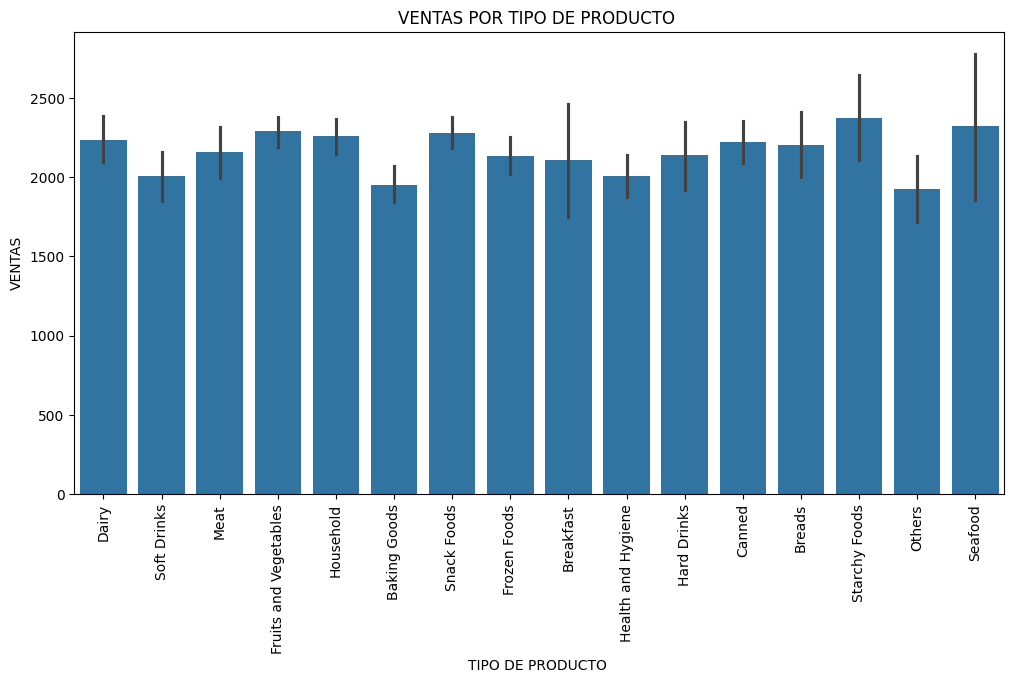

In [17]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=train,
    x="Item_Type", # TIPO DE PRODUCTO 
    y="Item_Outlet_Sales"
)
ax.set_title("VENTAS POR TIPO DE PRODUCTO ")
ax.set_xlabel("TIPO DE PRODUCTO ")
ax.set_ylabel("VENTAS")

plt.xticks(rotation=90)
plt.show()

TAMAÑO DEL LUGAR

In [18]:
train["Outlet_Size"].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

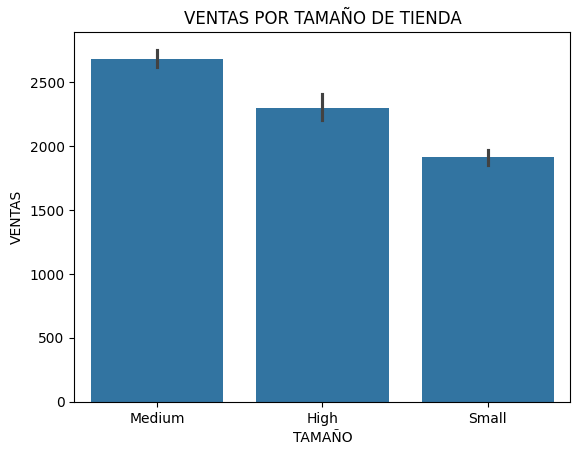

In [19]:
ax = sns.barplot(
    data=train,
    x="Outlet_Size", # TAMAÑO DEL LUGAR
    y="Item_Outlet_Sales"
)
ax.set_title("VENTAS POR TAMAÑO DE TIENDA")
ax.set_xlabel("TAMAÑO")
ax.set_ylabel("VENTAS")

plt.show()

TIPO DE TIENDA

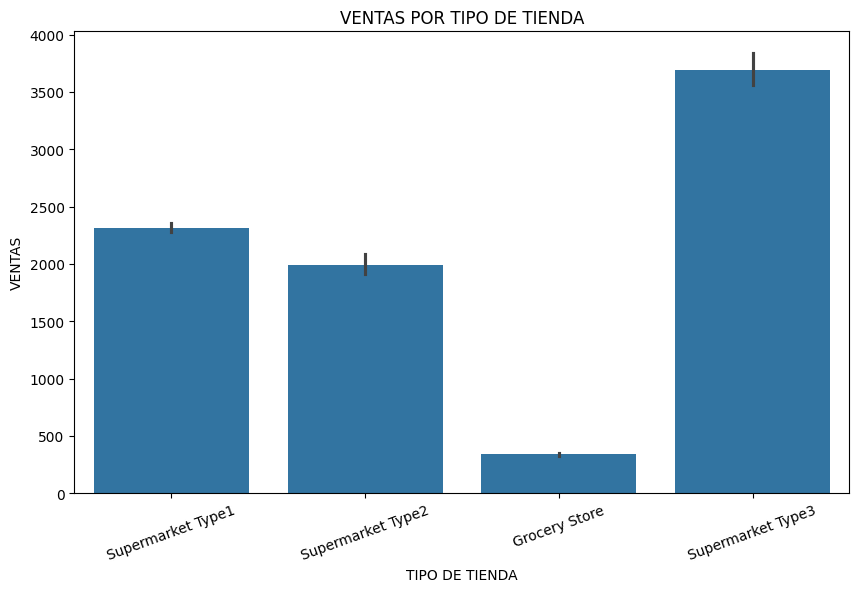

In [20]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=train,
    x="Outlet_Type", # TIPO DE MERCADO
    y="Item_Outlet_Sales"
)
ax.set_title("VENTAS POR TIPO DE TIENDA")
ax.set_xlabel("TIPO DE TIENDA")
ax.set_ylabel("VENTAS")

plt.xticks(rotation=20)
plt.show()

UBICACION DE TIENDA

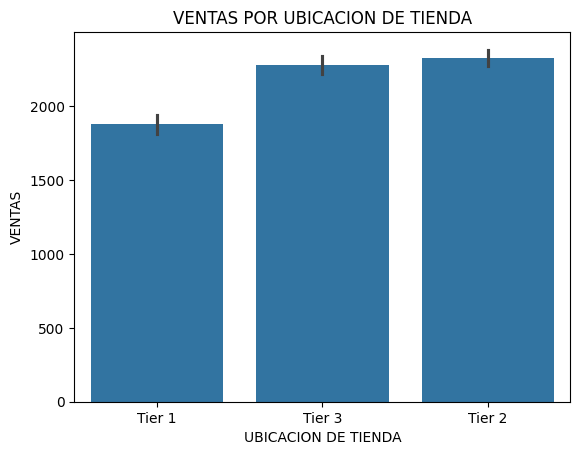

In [21]:
ax = sns.barplot(
    data=train,
    x="Outlet_Location_Type", # UBICACION DEL MERCADO
    y="Item_Outlet_Sales"
)
ax.set_title("VENTAS POR UBICACION DE TIENDA")
ax.set_xlabel("UBICACION DE TIENDA")
ax.set_ylabel("VENTAS")

plt.show()

### 2.2 Variables numéricas

VENTAS POR OBSERVACIÓN

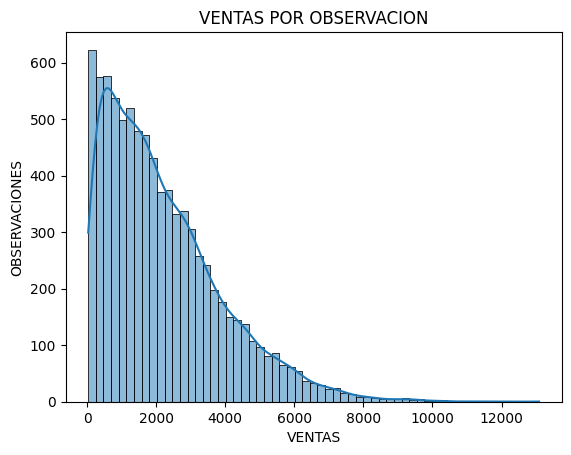

In [22]:
ax = sns.histplot(train["Item_Outlet_Sales"], kde=True)

ax.set_title("VENTAS POR OBSERVACION")
ax.set_xlabel("VENTAS")
ax.set_ylabel("OBSERVACIONES")
plt.show()

VENTAS POR VISIBILIDAD

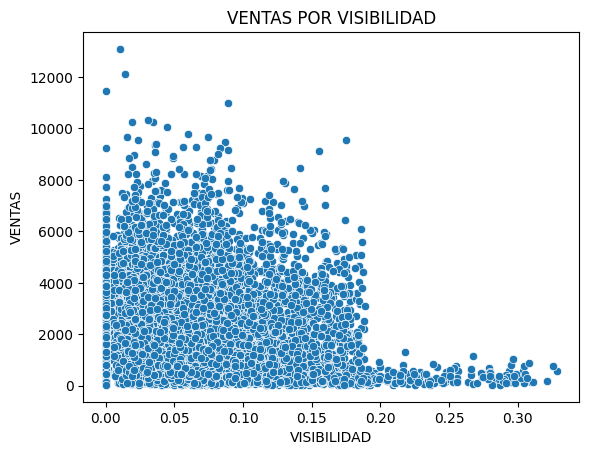

In [23]:
AX = sns.scatterplot(
    data=train,
    x="Item_Visibility", # VISIBILIDAD DEL PRODUCTO
    y="Item_Outlet_Sales"
)
AX.set_title("VENTAS POR VISIBILIDAD")
AX.set_xlabel("VISIBILIDAD")
AX.set_ylabel("VENTAS")

plt.show()

PRECIO DEL PRODUCTO POR VENTAS

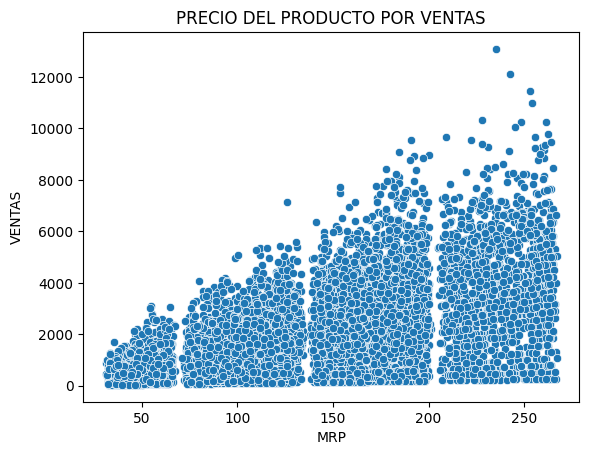

In [24]:
AX = sns.scatterplot(
    data=train,
    x="Item_MRP",
    y="Item_Outlet_Sales"
)
AX.set_title("PRECIO DEL PRODUCTO POR VENTAS")
AX.set_xlabel("MRP")
AX.set_ylabel("VENTAS")


plt.show()

### 2.3 Outliers

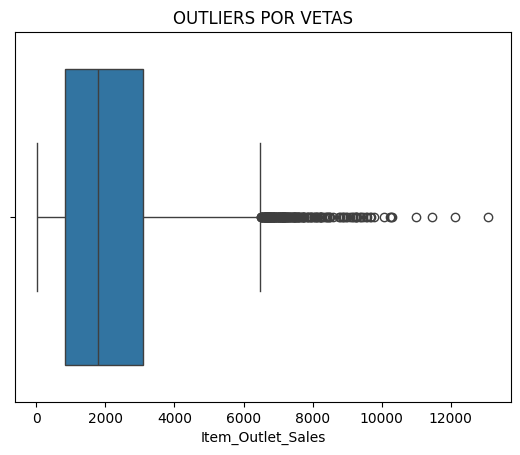

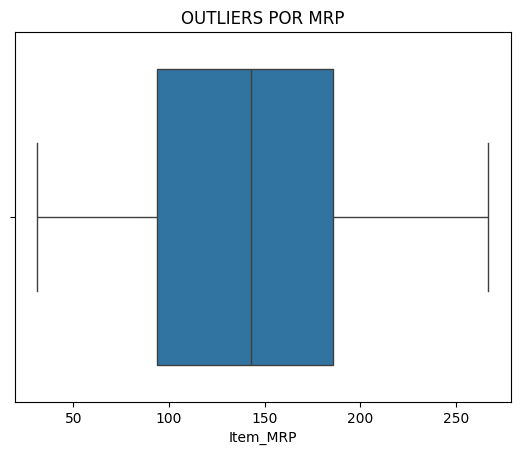

In [25]:
AX = sns.boxplot(x=train["Item_Outlet_Sales"])
AX.set_title("OUTLIERS POR VETAS")
plt.show()

AX1 = sns.boxplot(x=train["Item_MRP"])
AX1.set_title("OUTLIERS POR MRP")
plt.show()

MUESTRA SIN OUTLIERS POR VENTAS

TRAIN: (8523, 12)
SIN OUTL: (8337, 12)


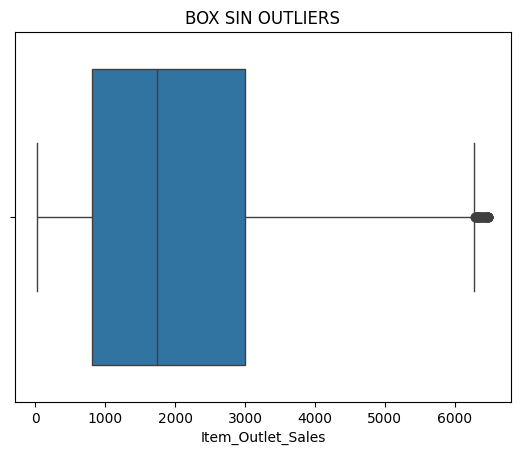

In [26]:
Q1 = train["Item_Outlet_Sales"].quantile(0.25) 
Q3 = train["Item_Outlet_Sales"].quantile(0.75)

IQR = Q3 - Q1
min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

train_sin_outliers = train[ (train["Item_Outlet_Sales"] >= min) & (train["Item_Outlet_Sales"] <= max) ]


print("TRAIN:", train.shape)
print("SIN OUTL:", train_sin_outliers.shape)


AX = sns.boxplot(x=train_sin_outliers["Item_Outlet_Sales"])
AX.set_title("BOX SIN OUTLIERS")
plt.show()

QUITAMOS LOS OUTLIERS QUE QUEDAN 

In [27]:
max = train_sin_outliers["Item_Outlet_Sales"].quantile(0.99)

train_sin_outliers = train_sin_outliers[ train_sin_outliers["Item_Outlet_Sales"] <= max ]

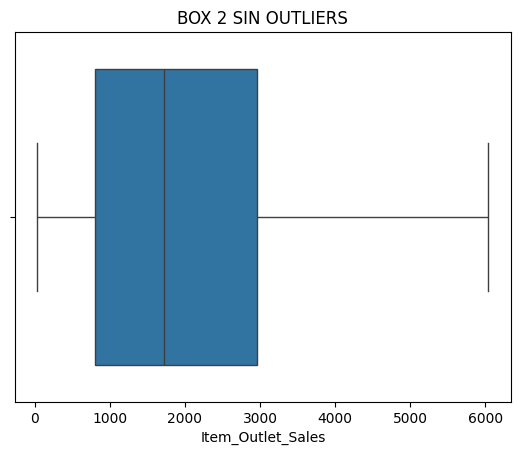

In [28]:
AX = sns.boxplot(x=train_sin_outliers["Item_Outlet_Sales"])
AX.set_title("BOX 2 SIN OUTLIERS")
plt.show()

### 2.4 CORRELACIÓN 

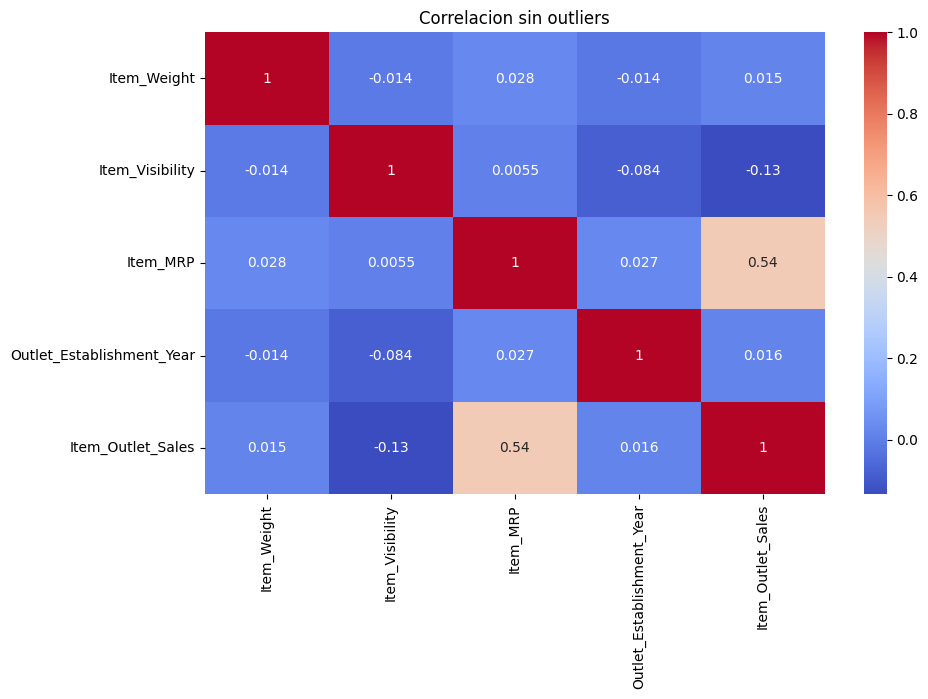

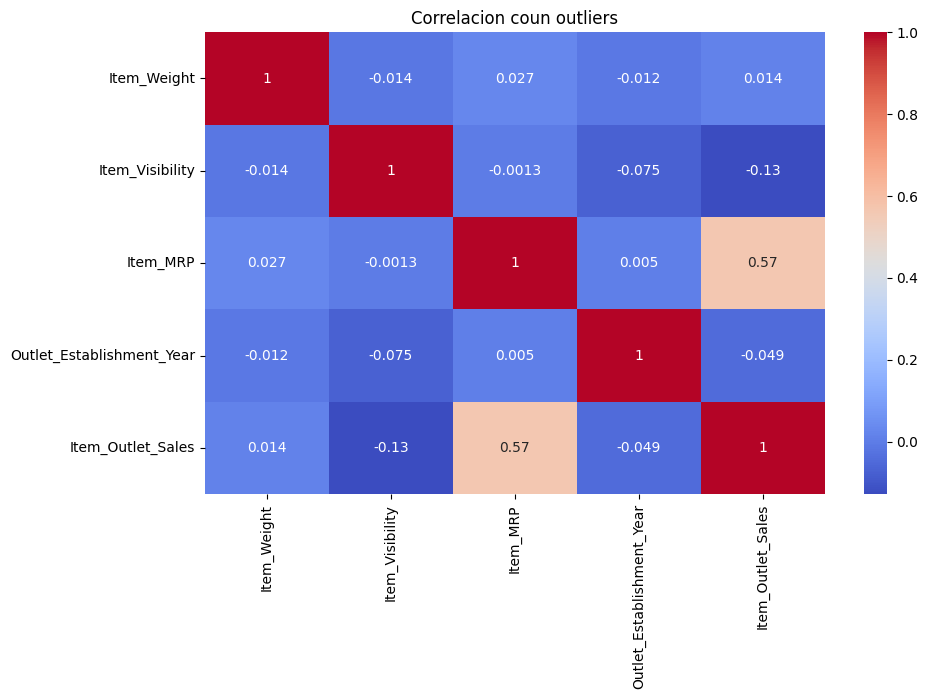

In [29]:
numericas = train_sin_outliers.select_dtypes(include=['int64', 'float64'])

correlacion = numericas.corr()

plt.figure(figsize=(10,6))
ax = sns.heatmap(correlacion, annot=True, cmap='coolwarm')
ax.set_title("Correlacion sin outliers")
plt.show()

numericas = train.select_dtypes(include=['int64', 'float64'])

correlacion = numericas.corr()

plt.figure(figsize=(10,6))
ax = sns.heatmap(correlacion, annot=True, cmap='coolwarm')
ax.set_title("Correlacion coun outliers")
plt.show()

> **OBSERVACIONES:**
> - **Supermarket Type3** presenta las ventas promedio más altas, mientras que **Grocery Store** registra las más bajas.
> - El **tipo de tienda** aparece como uno de los factores más discriminativos sobre las ventas.
> - El precio del producto (`Item_MRP`) muestra distintos rangos o bandas de comportamiento en relación con las ventas.
> - La variable `Item_Visibility` contiene valores iguales a 0, los cuales podrían corresponder a errores o faltantes de registro.
> - Se realizaron pruebas con y sin tratamiento de outliers, considerando que parte de los valores extremos podrían representar comportamientos reales del negocio.
> - La mayor correlación encontrada fue entre `Item_MRP` y `Item_Outlet_Sales`.

## 3. FEATURE
### 3.1 DESARROLLO

ANTIGUEDAD

In [30]:
train_sin_outliers["antiguedad"] = 2026 - train_sin_outliers["Outlet_Establishment_Year"]
train["antiguedad"] = 2026 - train["Outlet_Establishment_Year"]
test["antiguedad"] = 2026 - test["Outlet_Establishment_Year"]

PRECIO POR PESO

In [31]:
train_sin_outliers["precio_por_peso"] = ( train_sin_outliers["Item_MRP"] / train_sin_outliers["Item_Weight"])
train["precio_por_peso"] = ( train["Item_MRP"] / train["Item_Weight"])
test["precio_por_peso"] = (test["Item_MRP"] / test["Item_Weight"])

SEGMENTO POR PRECIO DE PRODUCTO

In [32]:
train_sin_outliers["producto_barato_caro"] = ( train_sin_outliers["Item_MRP"] > train_sin_outliers["Item_MRP"].median()).astype(int)
train["producto_barato_caro"] = ( train["Item_MRP"] > train["Item_MRP"].median()).astype(int)
test["producto_barato_caro"] = (test["Item_MRP"] > test["Item_MRP"].median() ).astype(int)

VISIBILIDAD POR PRECIO

In [33]:
train_sin_outliers["visibilidad_por_precio"] = (train_sin_outliers["Item_Visibility"] / train_sin_outliers["Item_MRP"] )
train["visibilidad_por_precio"] = (train["Item_Visibility"] / train["Item_MRP"] )
test["visibilidad_por_precio"] = (test["Item_Visibility"] / test["Item_MRP"])

SEGMENTO POR VISIBILIDAD

In [34]:
train_sin_outliers["clasificacion_visibilidad"] = (train_sin_outliers["Item_Visibility"] > train_sin_outliers["Item_Visibility"].median()).astype(int)
train["clasificacion_visibilidad"] = (train["Item_Visibility"] > train["Item_Visibility"].median()).astype(int)
test["clasificacion_visibilidad"] = (test["Item_Visibility"] > test["Item_Visibility"].median()).astype(int)

### 3.2 GRAFICOS DE FEATURES

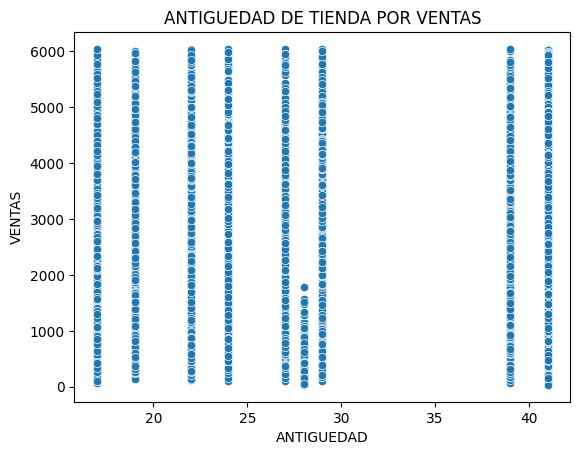

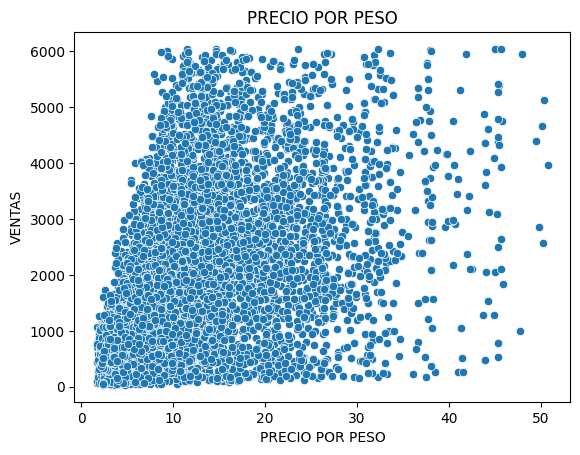

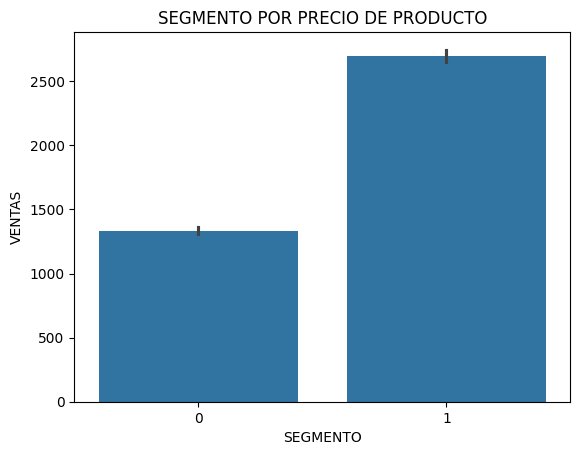

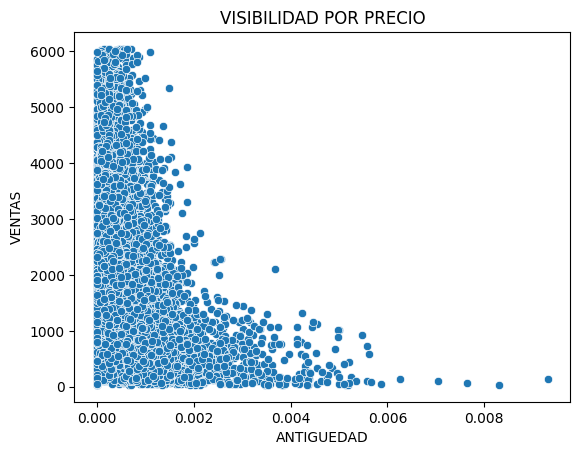

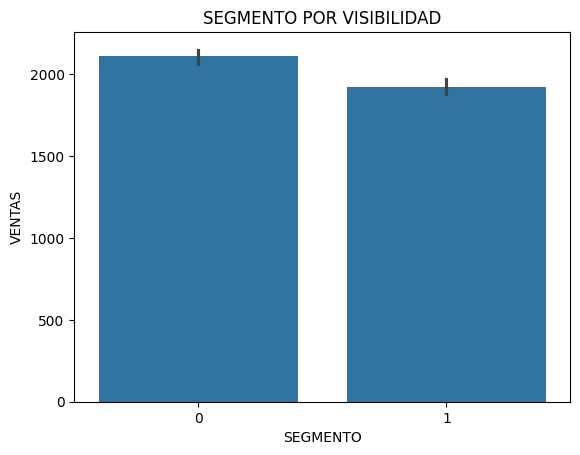

In [35]:
# ANTIGUEDAD
AX = sns.scatterplot(
    data=train_sin_outliers,
    x="antiguedad",
    y="Item_Outlet_Sales"
)
AX.set_title("ANTIGUEDAD DE TIENDA POR VENTAS")
AX.set_xlabel("ANTIGUEDAD")
AX.set_ylabel("VENTAS")
plt.show()

# PRECIO POR PESO
AX = sns.scatterplot(
    data=train_sin_outliers,
    x="precio_por_peso",
    y="Item_Outlet_Sales"
)
AX.set_title("PRECIO POR PESO")
AX.set_xlabel("PRECIO POR PESO")
AX.set_ylabel("VENTAS")
plt.show()

# SEGMENTO POR PRECIO DE PRODUCTO
AX = sns.barplot(
    data=train_sin_outliers,
    x="producto_barato_caro",
    y="Item_Outlet_Sales"
)
AX.set_title("SEGMENTO POR PRECIO DE PRODUCTO")
AX.set_xlabel("SEGMENTO")
AX.set_ylabel("VENTAS")
plt.show()

# VISIBILIDAD POR PRECIO
AX = sns.scatterplot(
    data=train_sin_outliers,
    x="visibilidad_por_precio",
    y="Item_Outlet_Sales"
)
AX.set_title("VISIBILIDAD POR PRECIO")
AX.set_xlabel("ANTIGUEDAD")
AX.set_ylabel("VENTAS")
plt.show()

# SEGMENTO POR VISIBILIDAD
AX = sns.barplot(
    data=train_sin_outliers,
    x="clasificacion_visibilidad",
    y="Item_Outlet_Sales"
)
AX.set_title("SEGMENTO POR VISIBILIDAD")
AX.set_xlabel("SEGMENTO")
AX.set_ylabel("VENTAS")
plt.show()

## 4. Preparación del dataset final
### 4.1 Filtración de campos

In [36]:
# QUITAMOS ESTOS CAMPOS QUE NO TIENEN RELEVANCION Y QUE NO TIENEN INFORMACIÓN NECESARIA PARA EL MODELO, 
# QUITAMOS PESO DE PRODUCTO Y TAMAÑO DE TIENDA POR LA CANTIDAD DE VALORES NULOS
columnas_para_borrar = ["Item_Identifier", "Outlet_Identifier","Item_Weight", "Outlet_Size","precio_por_peso"]
train_clean_sin_outl = train_sin_outliers.drop(columnas_para_borrar, axis=1)
train_clean = train.drop(columnas_para_borrar, axis=1)
test_clean = test.drop(columnas_para_borrar, axis=1)

In [37]:
train_clean_sin_outl.isnull().sum()

Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
antiguedad                   0
producto_barato_caro         0
visibilidad_por_precio       0
clasificacion_visibilidad    0
dtype: int64

### 4.2 Encoding de variables categóricas

In [38]:
train_clean = pd.get_dummies(train_clean, drop_first=True)
train_clean_sin_outl = pd.get_dummies(train_clean_sin_outl, drop_first=True)
test_clean = pd.get_dummies(test_clean, drop_first=True)

In [39]:
train_clean.head(2)

,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,antiguedad,producto_barato_caro,visibilidad_por_precio,clasificacion_visibilidad,Item_Fat_Content_Regular,Item_Type_Breads,...,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,0.016047,249.8092,1999,3735.1380,27,1,0.000064,0,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.019278,48.2692,2009,443.4228,17,0,0.000399,0,True,False,...,False,False,False,True,False,False,True,False,True,False


### 4.3 Guardamos los data sets

In [40]:
train_clean.to_csv(r"../data/train_clean.csv", index=False)
train_clean_sin_outl.to_csv(r"../data/train_clean_sin_outl.csv", index=False)
test_clean.to_csv(r"../data/test_clean.csv", index=False)

> **OBSERVACIONES:**
> - Se eliminaron los campos que presentaban problemas debido a la gran cantidad de valores nulos. Si bien era posible imputarlos utilizando promedios del conjunto de entrenamiento, se decidió descartarlos para evitar introducir ruido y afectar la calidad de los datos.
> - Los datasets quedaron preparados para la etapa final de modelado.
> - Se generaron versiones con y sin outliers para poder comparar el impacto de estos registros en el rendimiento de los modelos.